In [ ]:
import json
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import rdflib
from rdflib import Graph, RDF, RDFS, OWL
import spacy
import re

# Configuration
JSON_INPUT_PATH = "/home/matt/Proj/Hermeticav2/results/DualAnnotation/MMLU_highschool_Chem_Full_Dual_annotation0.json"
ONTOLOGY_PATH = "/home/matt/Proj/Hermeticav2/data/ontologies/Chemistry/chebi.owl"
OUTPUT_PREFIX = "domain_relevance"

class OntologyRuleAnalyzer:
    def __init__(self, ontology_path):
        """Initialize with ontology path"""
        self.ontology_path = ontology_path
        self.domain_terms = set()
        self.rules = {"disjoint": [], "subclass": [], "equivalent": []}
        self.nlp = self._load_nlp()
        self._load_ontology()
    
    def _load_nlp(self):
        """Load spaCy NLP model"""
        try:
            return spacy.load("en_core_web_sm")
        except OSError:
            spacy.cli.download("en_core_web_sm")
            return spacy.load("en_core_web_sm")
    
    def _load_ontology(self):
        """Load ontology and extract terms and rules"""
        g = Graph()
        g.parse(self.ontology_path)
        
        # Extract domain terms
        for s, p, o in g.triples((None, RDFS.label, None)):
            if isinstance(o, rdflib.term.Literal):
                self.domain_terms.add(str(o).lower())
        
        # Extract disjoint rules
        for s, p, o in g.triples((None, OWL.disjointWith, None)):
            s_label = self._get_label(g, s)
            o_label = self._get_label(g, o)
            if s_label and o_label:
                self.rules["disjoint"].append((s_label.lower(), o_label.lower()))
        
        # Extract subclass rules
        for s, p, o in g.triples((None, RDFS.subClassOf, None)):
            if not isinstance(o, rdflib.term.BNode):
                s_label = self._get_label(g, s)
                o_label = self._get_label(g, o)
                if s_label and o_label:
                    self.rules["subclass"].append((s_label.lower(), o_label.lower()))
        
        # Extract equivalent class rules
        for s, p, o in g.triples((None, OWL.equivalentClass, None)):
            if not isinstance(o, rdflib.term.BNode):
                s_label = self._get_label(g, s)
                o_label = self._get_label(g, o)
                if s_label and o_label:
                    self.rules["equivalent"].append((s_label.lower(), o_label.lower()))
        
        print(f"Loaded ontology with {len(self.domain_terms)} terms")
        print(f"Extracted {len(self.rules['disjoint'])} disjoint rules")
        print(f"Extracted {len(self.rules['subclass'])} subclass rules")
    
    def _get_label(self, graph, entity):
        """Get entity label"""
        for _, _, label in graph.triples((entity, RDFS.label, None)):
            return str(label)
        if isinstance(entity, rdflib.term.URIRef):
            return entity.split("/")[-1].replace("_", " ")
        return None
    
    def extract_statements(self, text):
        """Extract subject-relation-object statements from text"""
        doc = self.nlp(text)
        statements = []
        
        for sent in doc.sents:
            for token in sent:
                # Look for verbs
                if token.pos_ == "VERB" or (token.pos_ == "AUX" and token.dep_ == "ROOT"):
                    # Find subjects and objects
                    subjects = [subj for subj in token.children if subj.dep_ in ("nsubj", "nsubjpass")]
                    objects = [obj for obj in token.children if obj.dep_ in ("dobj", "pobj", "attr")]
                    
                    # Create statements
                    for subj in subjects:
                        for obj in objects:
                            statements.append({
                                "subject": subj.text.lower(),
                                "relation": token.lemma_.lower(),
                                "object": obj.text.lower(),
                                "sentence": sent.text
                            })
        
        return statements
    
    def extract_domain_concepts(self, text):
        """Extract domain concepts from text"""
        text_lower = text.lower()
        found_concepts = set()
        
        # Find mentions of domain terms
        for term in self.domain_terms:
            if term in text_lower:
                # Simple boundary check
                pattern = r'\b' + re.escape(term) + r'\b'
                if re.search(pattern, text_lower):
                    found_concepts.add(term)
        
        return found_concepts
    
    def check_violations(self, statements):
        """Check for rule violations in statements"""
        violations = []
        
        for stmt in statements:
            subj = stmt["subject"]
            obj = stmt["object"]
            rel = stmt["relation"]
            
            # Only consider statements where both subject and object are domain terms
            if subj in self.domain_terms and obj in self.domain_terms:
                # Check is-a type relations
                if rel in ("be", "is", "are", "was", "were"):
                    # Check disjoint violations
                    for c1, c2 in self.rules["disjoint"]:
                        if (subj == c1 and obj == c2) or (subj == c2 and obj == c1):
                            violations.append({
                                "type": "disjoint_violation",
                                "statement": stmt["sentence"],
                                "explanation": f"'{subj}' and '{obj}' are disjoint classes"
                            })
                    
                    # Check hierarchy violations
                    for subclass, superclass in self.rules["subclass"]:
                        # Statement claims the superclass is a type of subclass (reversed hierarchy)
                        if subj == superclass and obj == subclass:
                            violations.append({
                                "type": "hierarchy_violation",
                                "statement": stmt["sentence"],
                                "explanation": f"'{subclass}' is a subclass of '{superclass}', not vice versa"
                            })
        
        return violations
    
    def analyze_response(self, response_text):
        """Analyze a response for domain relevance and rule violations"""
        # Extract statements and concepts
        statements = self.extract_statements(response_text)
        concepts = self.extract_domain_concepts(response_text)
        
        # Check for violations
        violations = self.check_violations(statements)
        
        # Calculate metrics
        domain_relevance = len(concepts) / max(1, len(statements)) * 100
        
        return {
            "domain_concepts": list(concepts),
            "domain_concept_count": len(concepts),
            "domain_relevance": domain_relevance,
            "statement_count": len(statements),
            "violation_count": len(violations),
            "has_violations": len(violations) > 0,
            "violations": violations
        }
    
    def analyze_dataset(self, json_path, output_prefix):
        """Analyze a dataset of responses"""
        # Load data
        with open(json_path, "r") as f:
            data = json.load(f)
        
        results = []
        
        # Process each response
        for model_name, model_data in data.items():
            # Handle both response types if present
            if "onto_model_response" in model_data and "raw_model_response" in model_data:
                for resp_type in ["onto_model_response", "raw_model_response"]:
                    if resp_type in model_data:
                        result = self.analyze_response(model_data[resp_type])
                        result["model"] = model_name
                        result["response_type"] = resp_type
                        result["base_model"] = model_name.split('_')[0] if '_' in model_name else model_name
                        results.append(result)
            # Handle single response format
            elif "response" in model_data:
                result = self.analyze_response(model_data["response"])
                result["model"] = model_name
                result["response_type"] = "standard"
                result["base_model"] = model_name.split('_')[0] if '_' in model_name else model_name
                results.append(result)
        
        # Convert to DataFrame
        df = pd.DataFrame(results)
        
        # Save results
        df.to_csv(f"{output_prefix}_results.csv", index=False)
        
        # Create visualizations
        self.create_visualizations(df, output_prefix)
        
        return df
    
    def create_visualizations(self, df, output_prefix):
        """Create visualizations from analysis results"""
        # Set plasma color palette
        sns.set_palette("plasma")
        
        # Only create comparisons if we have different response types
        if 'response_type' in df.columns and len(df['response_type'].unique()) > 1:
            # Calculate summary by response type
            summary = df.groupby('response_type').agg({
                'domain_relevance': 'mean',
                'violation_count': 'mean',
                'has_violations': 'mean'
            }).reset_index()
            
            # Domain relevance comparison
            plt.figure(figsize=(10, 6))
            sns.barplot(x='response_type', y='domain_relevance', data=summary, palette="plasma")
            plt.title('Domain Relevance by Response Type', size=15)
            plt.ylabel('Domain Relevance %')
            plt.tight_layout()
            plt.savefig(f"{output_prefix}_domain_relevance.png")
            
            # Violation rate comparison
            plt.figure(figsize=(10, 6))
            sns.barplot(x='response_type', y='has_violations', data=summary, palette="plasma")
            plt.title('Rule Violation Rate by Response Type', size=15)
            plt.ylabel('Proportion with Violations')
            plt.tight_layout()
            plt.savefig(f"{output_prefix}_violation_rate.png")
            
            # Compare models if we have more than one
            if len(df['base_model'].unique()) > 1:
                # Group by model and response type
                model_summary = df.groupby(['base_model', 'response_type']).agg({
                    'has_violations': 'mean'
                }).reset_index()
                
                # Create heatmap
                violation_pivot = model_summary.pivot(
                    index='base_model', 
                    columns='response_type', 
                    values='has_violations'
                )
                
                plt.figure(figsize=(12, 8))
                sns.heatmap(violation_pivot, annot=True, cmap="plasma", fmt='.2f')
                plt.title('Rule Violation Rate by Model and Response Type', size=15)
                plt.tight_layout()
                plt.savefig(f"{output_prefix}_model_violations.png")
                
                # Calculate improvement
                if all(rt in violation_pivot.columns for rt in ['onto_model_response', 'raw_model_response']):
                    improvement = violation_pivot['raw_model_response'] - violation_pivot['onto_model_response']
                    
                    plt.figure(figsize=(10, 6))
                    improvement.plot(kind='bar', color=sns.color_palette("plasma", 1))
                    plt.axhline(y=0, color='r', linestyle='-', alpha=0.3)
                    plt.title('Reduction in Rule Violations: Onto vs Raw', size=15)
                    plt.xlabel('Model')
                    plt.ylabel('Violation Rate Reduction')
                    plt.tight_layout()
                    plt.savefig(f"{output_prefix}_violation_improvement.png")
        
        print(f"Saved visualizations with prefix: {output_prefix}")

# Main execution
if __name__ == "__main__":
    analyzer = OntologyRuleAnalyzer(ONTOLOGY_PATH)
    analyzer.analyze_dataset(JSON_INPUT_PATH, OUTPUT_PREFIX)

Loaded ontology with 202232 terms
Extracted 0 disjoint rules
Extracted 280873 subclass rules


In [1]:
import owlready2 as owl
import pandas as pd

def extract_chebi_rules():
    """
    Extract logical rules from the ChEBI ontology.
    
    Returns:
        A list of dictionaries representing rules from the ontology
    """
    # Load the ChEBI ontology
    # You can download it from: https://ftp.ebi.ac.uk/pub/databases/chebi/ontology/
    chebi = owl.get_ontology("/home/matt/Proj/Hermeticav2/data/ontologies/Chemistry/chebi.owl").load()
    
    rules = []
    
    # Extract class hierarchy (is-a relationships)
    for cls in chebi.classes():
        for parent in cls.is_a:
            if isinstance(parent, owl.entity.ThingClass):
                rules.append({
                    "rule_type": "subclass",
                    "subject": cls.name,
                    "predicate": "rdfs:subClassOf",
                    "object": parent.name
                })
    
    # Extract property restrictions
    for cls in chebi.classes():
        for restriction in [r for r in cls.is_a if isinstance(r, owl.class_construct.Restriction)]:
            rules.append({
                "rule_type": "restriction",
                "subject": cls.name,
                "predicate": restriction.property.name,
                "object": restriction.value.name if hasattr(restriction.value, "name") else str(restriction.value),
                "restriction_type": type(restriction).__name__
            })
    
    # Extract equivalence relationships
    for cls in chebi.classes():
        for equivalent in cls.equivalent_to:
            if isinstance(equivalent, owl.entity.ThingClass):
                rules.append({
                    "rule_type": "equivalent",
                    "subject": cls.name,
                    "predicate": "owl:equivalentClass",
                    "object": equivalent.name
                })
    
    # Extract disjointness
    for cls in chebi.classes():
        for disjoint in cls.disjoints():
            for d in disjoint.entities:
                if d != cls:
                    rules.append({
                        "rule_type": "disjoint",
                        "subject": cls.name,
                        "predicate": "owl:disjointWith",
                        "object": d.name
                    })
    
    return rules

def save_rules_to_csv(rules, filename="chebi_rules.csv"):
    """Save extracted rules to a CSV file"""
    df = pd.DataFrame(rules)
    df.to_csv(filename, index=False)
    print(f"Saved {len(rules)} rules to {filename}")
    return df

if __name__ == "__main__":
    rules = extract_chebi_rules()
    save_rules_to_csv(rules)

Saved 392989 rules to chebi_rules.csv


Raw Model Violation Rate: 0.9536945812807882
Ontology Model Violation Rate: 1.638423645320197


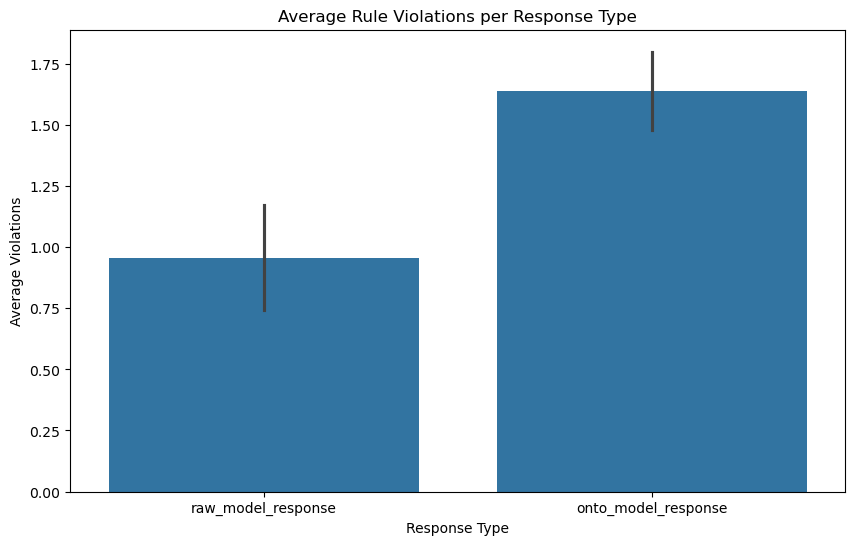

In [5]:
import json
import owlready2 as owl
import spacy
from collections import defaultdict
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

class OntologyRuleValidator:
    def __init__(self, owl_path):
        self.onto = owl.get_ontology(owl_path).load()
        self.nlp = spacy.load("en_core_web_sm")
        self.rules = self._extract_ontology_rules()
        
    def _extract_ontology_rules(self):
        """Extract ontology relationships and constraints"""
        rules = {
            'subclasses': defaultdict(set),
            'disjoints': defaultdict(set),
            'properties': defaultdict(dict)
        }
        
        # Extract subclass relationships
        for cls in self.onto.classes():
            for parent in cls.is_a:
                if isinstance(parent, owl.entity.ThingClass):
                    rules['subclasses'][cls.name].add(parent.name)
                    
        # Extract disjoint relationships
        for cls in self.onto.classes():
            for disjoint_set in cls.disjoints():
                for disjoint_cls in disjoint_set.entities:
                    if disjoint_cls != cls:
                        rules['disjoints'][cls.name].add(disjoint_cls.name)
                        
        # Extract property constraints
        for prop in self.onto.properties():
            rules['properties'][prop.name] = {
                'domain': {d.name for d in prop.domain},
                'range': {r.name for r in prop.range}
            }
            
        return rules

    def _extract_response_relationships(self, text):
        """Extract chemical relationships from response text"""
        doc = self.nlp(text)
        relationships = []
        
        # Pattern-based extraction
        for sent in doc.sents:
            # Handle "X has Y" relationships
            if 'has' in sent.text.lower():
                parts = sent.text.split('has')
                if len(parts) > 1:
                    subject = parts[0].strip()
                    predicate = 'has'
                    obj = parts[1].strip()
                    relationships.append((subject, predicate, obj))
            
            # Handle comparative relationships
            if 'than' in sent.text.lower():
                parts = sent.text.split('than')
                if len(parts) > 1:
                    subject = parts[0].split()[-1].strip()
                    obj = parts[1].strip()
                    relationships.append((subject, 'comparative', obj))
                    
        return relationships

    def validate_response(self, response):
        """Validate response against ontology rules"""
        violations = []
        relationships = self._extract_response_relationships(response)
        
        for subj, pred, obj in relationships:
            # Check subclass relationships
            if pred == 'has':
                if obj not in self.rules['subclasses'].get(subj, set()):
                    violations.append({
                        'type': 'invalid_subclass',
                        'subject': subj,
                        'predicate': pred,
                        'object': obj
                    })
            
            # Check disjoint relationships
            if subj in self.rules['disjoints'] and obj in self.rules['disjoints'][subj]:
                violations.append({
                    'type': 'disjoint_violation',
                    'subject': subj,
                    'predicate': pred,
                    'object': obj
                })
                
        return violations

class ResponseAnalyzer:
    def __init__(self, owl_path, response_files):
        self.validator = OntologyRuleValidator(owl_path)
        self.response_files = response_files
        self.results = []
        
    def _process_responses(self):
        """Process all response files"""
        for file_path in self.response_files:
            with open(file_path) as f:
                data = json.load(f)
                
            for resp_id, entry in data.items():
                # Analyze both response types
                for resp_type in ['raw_model_response', 'onto_model_response']:
                    response = entry.get(resp_type, '')
                    if response:
                        violations = self.validator.validate_response(response)
                        self.results.append({
                            'response_id': resp_id,
                            'type': resp_type,
                            'violations': len(violations),
                            'violation_details': violations
                        })
    
    def generate_report(self):
        """Generate comparative analysis report"""
        self._process_responses()
        df = pd.DataFrame(self.results)
        
        # Comparative analysis
        summary = df.groupby('type').agg({
            'violations': ['mean', 'sum'],
            'response_id': 'count'
        }).reset_index()
        
        # Visualization
        plt.figure(figsize=(10, 6))
        sns.barplot(x='type', y='violations', data=df, estimator=np.mean)
        plt.title('Average Rule Violations per Response Type')
        plt.ylabel('Average Violations')
        plt.xlabel('Response Type')
        plt.savefig('violation_comparison.png')
        
        return df, summary

# Configuration
CHEBI_OWL = "/home/matt/Proj/Hermeticav2/data/ontologies/Chemistry/chebi.owl"
RESPONSE_FILES = ["/home/matt/Proj/Hermeticav2/results/ResponseAnnotation/MMLU_highschool_Chem_Full_A_annotation1.json"]

# Run analysis
analyzer = ResponseAnalyzer(CHEBI_OWL, RESPONSE_FILES)
results_df, summary_df = analyzer.generate_report()

print("Raw Model Violation Rate:", 
      summary_df[summary_df['type'] == 'raw_model_response']['violations']['mean'].values[0])
print("Ontology Model Violation Rate:", 
      summary_df[summary_df['type'] == 'onto_model_response']['violations']['mean'].values[0])